# Taller: Diseño y Optimización de un MLP Profundo

**Curso:** Técnicas de Inteligencia Artificial  
**Universidad Nacional de Colombia — Sede Bogotá**  
**Ingeniería Mecatrónica — Facultad de Ingeniería**  
**Profesor:** Flavio Prieto — faprietoo@unal.edu.co  
**Fecha:** Abril 2026

---

## Objetivo

Diseñar, entrenar y optimizar un Perceptrón Multicapa (MLP) para identificar personas
en un problema de clasificación multiclase usando el dataset **Olivetti Faces** (40 clases, 400 imágenes).

**Restricción:** No se permite el uso de redes convolucionales (CNN).


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)
from torch.utils.data import DataLoader, TensorDataset
import time, copy, warnings, pandas as pd

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch:     {torch.__version__}")

VERSION       = "rapida"
N_TRIALS      = 30 if VERSION == "rapida" else 80
MAX_EPOCHS    = 100 if VERSION == "rapida" else 150
PATIENCE      = 10 if VERSION == "rapida" else 15
N_CANDIDATES  = 10 if VERSION == "rapida" else 20
RETRAIN_EPOCHS = 150

print(f"\nVersión: {VERSION} | Trials: {N_TRIALS} | "
      f"Épocas máx: {MAX_EPOCHS} | Patience: {PATIENCE} | "
      f"Candidatos: {N_CANDIDATES}")


Dispositivo: cpu
PyTorch:     2.11.0+cu130

Versión: rapida | Trials: 30 | Épocas máx: 100 | Patience: 10 | Candidatos: 10


---
## Parte 1 — Preprocesamiento

### 1.1 Carga del dataset Olivetti Faces


In [8]:
faces = fetch_olivetti_faces(shuffle=False)
X, y = faces.data, faces.target

print(f"Dimensiones X: {X.shape}  (400 imágenes × 4096 píxeles)")
print(f"Clases:        {len(np.unique(y))} personas")
print(f"Imgs/persona:  {np.bincount(y)[0]}")
print(f"Rango valores: [{X.min():.2f}, {X.max():.2f}]")


Dimensiones X: (400, 4096)  (400 imágenes × 4096 píxeles)
Clases:        40 personas
Imgs/persona:  10
Rango valores: [0.00, 1.00]


### 1.2 Visualización exploratoria

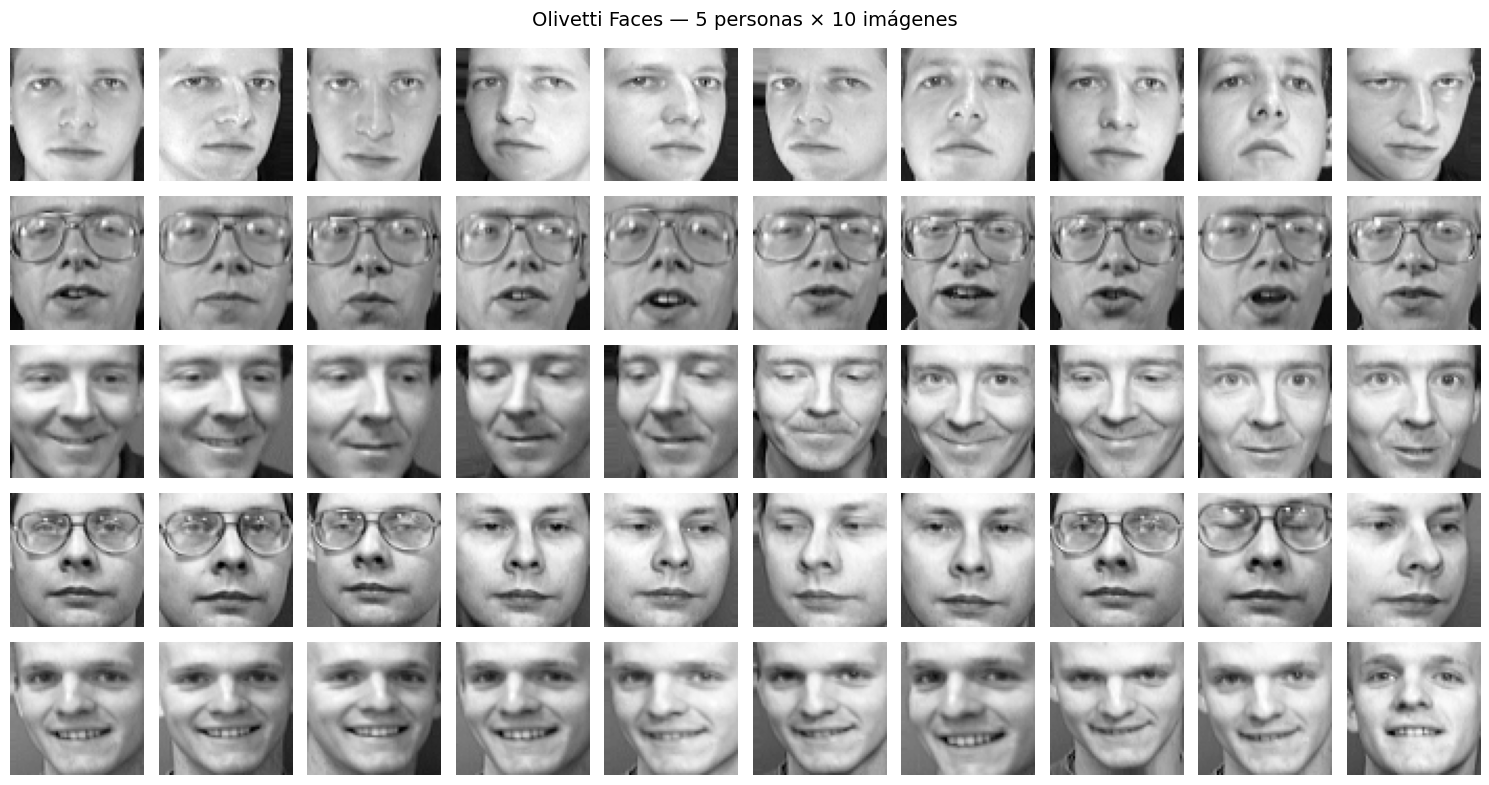

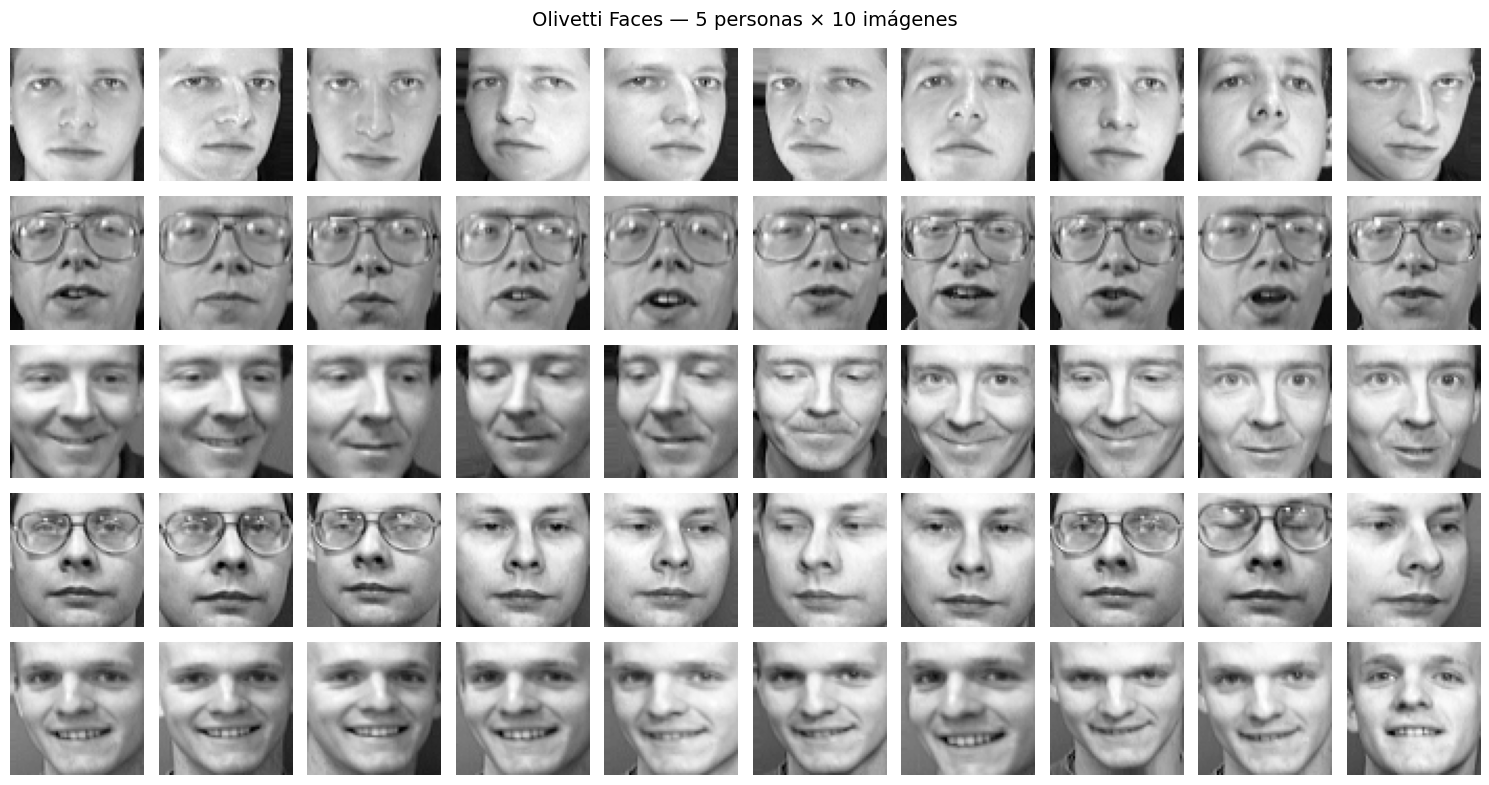

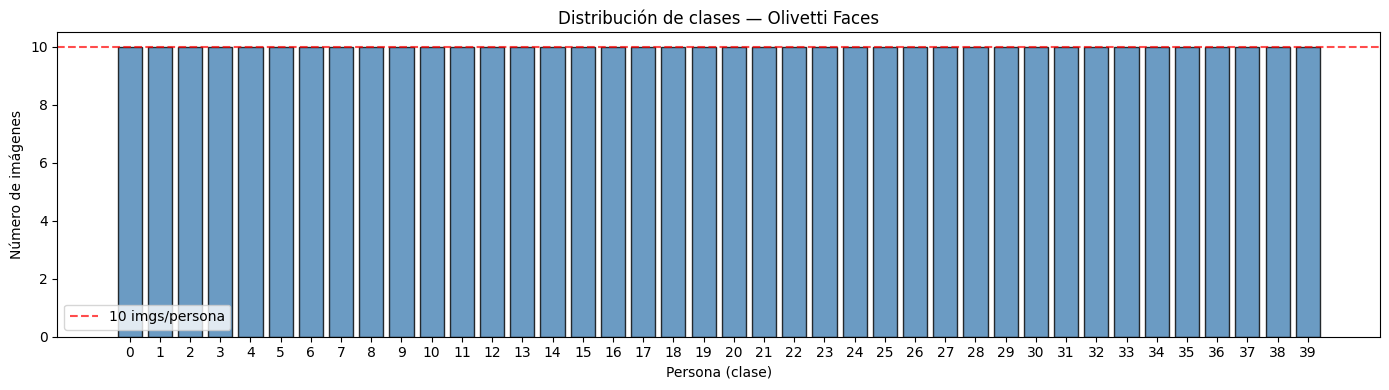

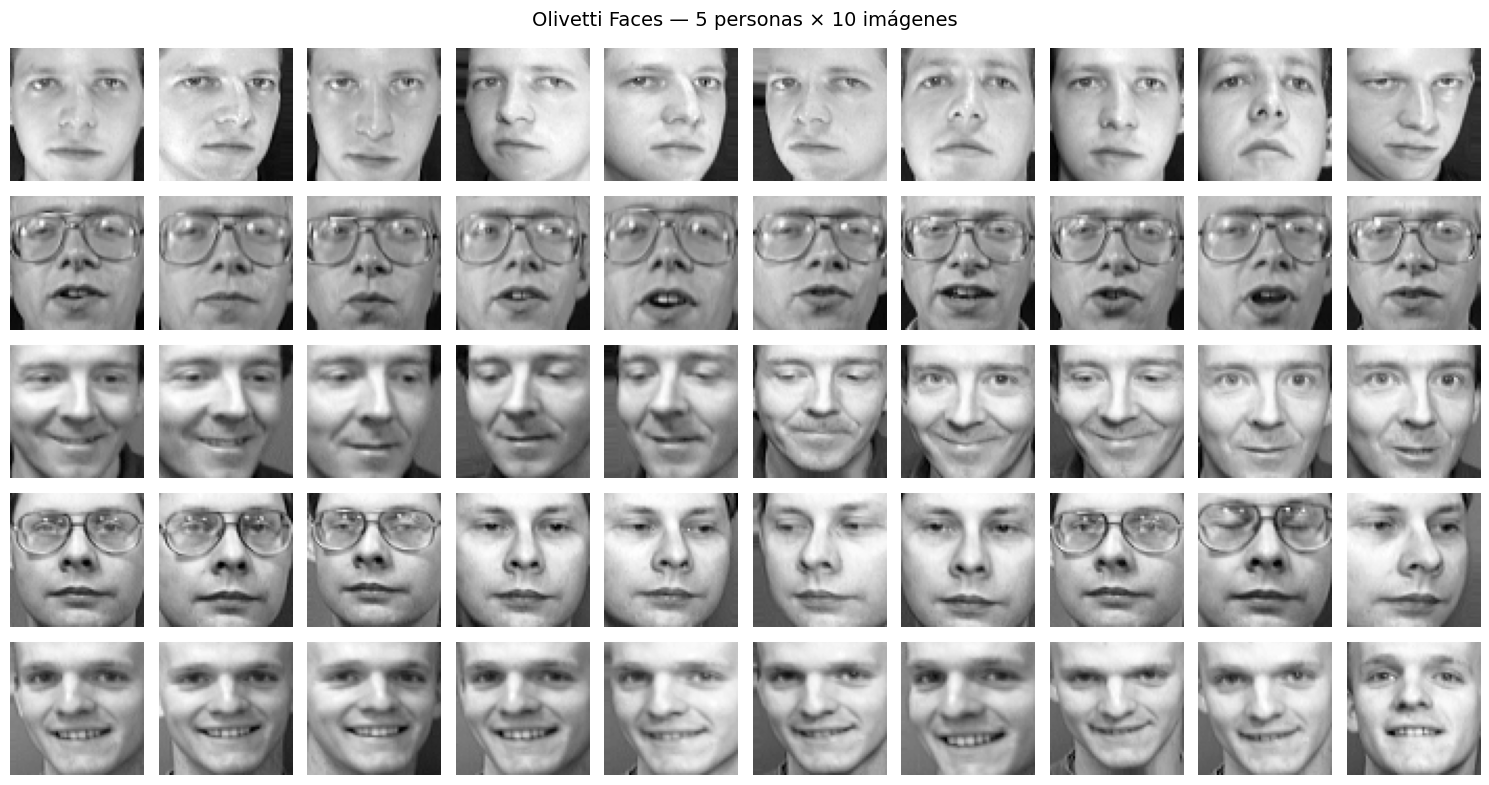

In [9]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
fig.suptitle("Olivetti Faces — 5 personas × 10 imágenes", fontsize=14)
for persona in range(5):
    for j, idx in enumerate(np.where(y == persona)[0]):
        axes[persona, j].imshow(faces.images[idx], cmap="gray")
        axes[persona, j].axis("off")
        if j == 0:
            axes[persona, j].set_ylabel(f"P{persona}", fontsize=10)
plt.tight_layout()
plt.savefig("fig_01_faces_grid.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.3 Distribución de clases

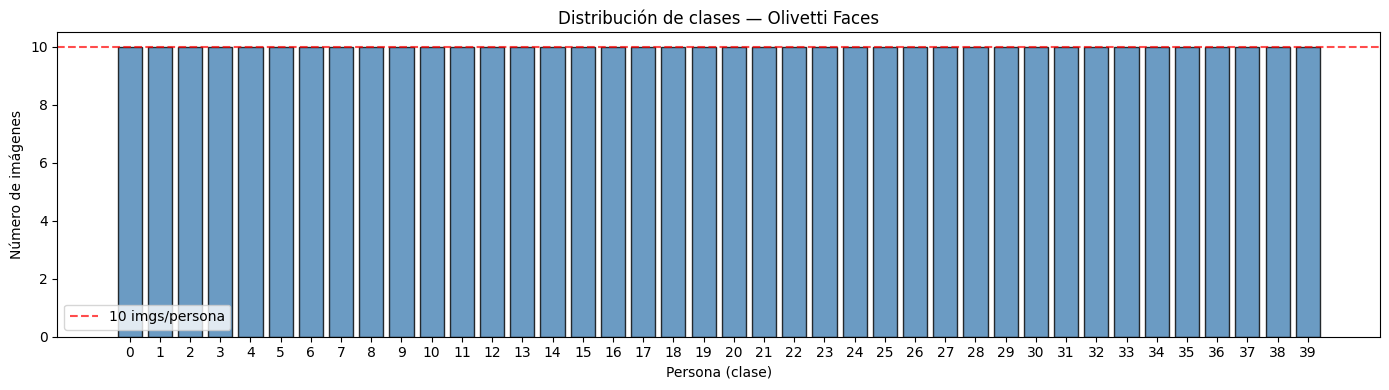

Dataset perfectamente balanceado: True


In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
counts = np.bincount(y)
ax.bar(range(40), counts, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Persona (clase)")
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases — Olivetti Faces")
ax.set_xticks(range(40))
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="10 imgs/persona")
ax.legend()
plt.tight_layout()
plt.savefig("fig_02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Dataset perfectamente balanceado: {bool(np.all(counts == 10))}")


### 1.4 Partición del dataset — Hold-out estratificado 60/20/20

Se reservan 2 imágenes por persona para validación y 2 para test, usando
`train_test_split` con `stratify=y` para mantener la proporción de clases.


In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

print("Partición Hold-out estratificado 60/20/20:")
for name, sy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    c = np.bincount(sy, minlength=40)
    print(f"  {name:5s}: {len(sy):3d} muestras "
          f"({len(sy)/len(y)*100:.0f}%) — imgs/persona: [{c.min()}, {c.max()}]")


Partición Hold-out estratificado 60/20/20:
  Train: 240 muestras (60%) — imgs/persona: [6, 6]
  Val  :  80 muestras (20%) — imgs/persona: [2, 2]
  Test :  80 muestras (20%) — imgs/persona: [2, 2]


### 1.5 Normalización y preparación de tensores

`StandardScaler` ajustado **solo** en train para evitar data leakage.


In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_val_t   = torch.tensor(X_val_sc,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,      dtype=torch.long)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

print(f"X_train: {X_train_t.shape}  y_train: {y_train_t.shape}")
print(f"X_val:   {X_val_t.shape}    y_val:   {y_val_t.shape}")
print(f"X_test:  {X_test_t.shape}   y_test:  {y_test_t.shape}")


X_train: torch.Size([240, 4096])  y_train: torch.Size([240])
X_val:   torch.Size([80, 4096])    y_val:   torch.Size([80])
X_test:  torch.Size([80, 4096])   y_test:  torch.Size([80])


### 1.6 Reducción de dimensionalidad con PCA

Se preparan versiones con 95% y 99% de varianza preservada para evaluar
si la reducción de dimensionalidad mejora el rendimiento del MLP.


PCA 95%: 4096 → 95 componentes (2.3% de dims originales)
PCA 99%: 4096 → 176 componentes (4.3% de dims originales)


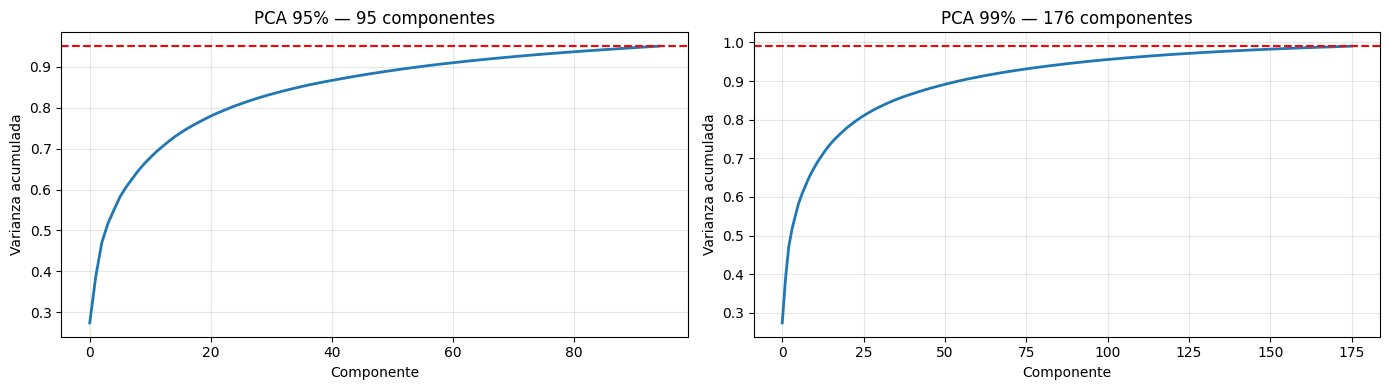

In [13]:
pca_options = {}
for ratio, label in [(0.95, "95"), (0.99, "99")]:
    pca = PCA(n_components=ratio, random_state=SEED)
    Xtr = pca.fit_transform(X_train_sc)
    Xvl = pca.transform(X_val_sc)
    Xte = pca.transform(X_test_sc)
    pca_options[label] = {
        "pca": pca,
        "X_train": torch.tensor(Xtr, dtype=torch.float32),
        "X_val":   torch.tensor(Xvl, dtype=torch.float32),
        "X_test":  torch.tensor(Xte, dtype=torch.float32),
        "n_components": pca.n_components_
    }
    print(f"PCA {label}%: 4096 → {pca.n_components_} componentes "
          f"({pca.n_components_/4096*100:.1f}% de dims originales)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, data) in zip(axes, pca_options.items()):
    cumvar = np.cumsum(data["pca"].explained_variance_ratio_)
    ax.plot(cumvar, linewidth=2)
    ax.axhline(y=float(f"0.{label}"), color="red", linestyle="--")
    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza acumulada")
    ax.set_title(f"PCA {label}% — {data['n_components']} componentes")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_03_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Parte 2 — Diseño del MLP

### 2.1 Clase `FullyConnectedNN`

La arquitectura implementa un MLP completamente denso para clasificación multiclase:
- Funciones de activación configurables (ReLU, Tanh, LeakyReLU, SELU)
- Batch Normalization opcional
- Dropout configurable por capa
- Número variable de capas ocultas


In [16]:
class FullyConnectedNN(nn.Module):
    """MLP dinámico con BatchNorm, Dropout y activación configurable."""

    ACT_MAP = {
        "relu": nn.ReLU, "tanh": nn.Tanh,
        "leaky_relu": nn.LeakyReLU, "selu": nn.SELU
    }

    def __init__(self, input_dim, output_dim, hidden_layers,
                 activation="relu", dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        act_fn = self.ACT_MAP.get(activation, nn.ReLU)
        prev = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Clase FullyConnectedNN definida.")


Clase FullyConnectedNN definida.


### 2.2 Funciones de entrenamiento y evaluación


In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                max_epochs, patience=10, grad_clip=None, l1_lambda=0,
                verbose=True):
    """Entrena el modelo con early stopping, gradient clipping y L1 opcional."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    wait = 0
    best_state = None

    for epoch in range(max_epochs):
        # --- Train ---
        model.train()
        tloss, tcorr, ttotal = 0.0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            tloss += loss.item() * yb.size(0)
            tcorr += (out.argmax(1) == yb).sum().item()
            ttotal += yb.size(0)

        # --- Validation ---
        model.eval()
        vloss, vcorr, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                loss = criterion(out, yb)
                vloss += loss.item() * yb.size(0)
                vcorr += (out.argmax(1) == yb).sum().item()
                vtotal += yb.size(0)

        tl = tloss / ttotal; ta = tcorr / ttotal
        vl = vloss / vtotal; va = vcorr / vtotal
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        if vl < best_val_loss:
            best_val_loss = vl
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  Early stopping en época {epoch+1}")
                break

        if verbose and (epoch + 1) % 25 == 0:
            print(f"  Época {epoch+1:3d}: tloss={tl:.4f} vloss={vl:.4f} "
                  f"tacc={ta:.4f} vacc={va:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    history["epochs_trained"] = len(history["train_loss"])
    history["best_val_loss"] = best_val_loss
    return history


def evaluate_model(model, loader):
    """Retorna (predictions, labels) como arrays numpy."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb).argmax(1).numpy())
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)


def plot_curves(history, title=""):
    """Grafica loss y accuracy de entrenamiento vs validación."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history["train_loss"]) + 1)
    ax1.plot(ep, history["train_loss"], "b-", label="Train", lw=2)
    ax1.plot(ep, history["val_loss"],   "r-", label="Val",   lw=2)
    ax1.set(xlabel="Época", ylabel="Loss", title=f"Loss — {title}")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(ep, history["train_acc"], "b-", label="Train", lw=2)
    ax2.plot(ep, history["val_acc"],   "r-", label="Val",   lw=2)
    ax2.set(xlabel="Época", ylabel="Accuracy", title=f"Accuracy — {title}")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

print("Funciones de entrenamiento y evaluación definidas.")


Funciones de entrenamiento y evaluación definidas.


### 2.3–2.4 Modelo base y entrenamiento

Arquitectura inicial: **[4096 → 512 → 256 → 128 → 40]**

| Decisión | Elección | Justificación |
|---|---|---|
| Capa de salida | 40 logits | Una salida por clase; `CrossEntropyLoss` aplica `LogSoftmax` internamente por estabilidad numérica |
| Activación | ReLU | Mantiene gradientes estables y bajo costo computacional |
| Pérdida | CrossEntropyLoss | Equivale a Softmax + NLL para clasificación multiclase en PyTorch |
| Optimizador | Adam, lr=1e-3 | Punto de partida adecuado para entrenamiento por gradiente en redes densas |
| Dropout | 0.3 | Regularización contra sobreajuste con 4096 features y 240 muestras |
| BatchNorm | Sí | Estabiliza el entrenamiento en redes profundas |


Modelo base: 2,268,840 parámetros
FullyConnectedNN(
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=40, bias=True)
  )
)

Entrenando modelo base...
  Época  25: tloss=0.1928 vloss=0.2853 tacc=1.0000 vacc=0.9625
  Época  50: tloss=0.0449 vloss=0.1418 tacc=1.0000 vacc=0.9625
  Época  75: tloss=0.0301 vloss=0.0882 tacc=1.0000 vacc=0.9875
  Early stoppin

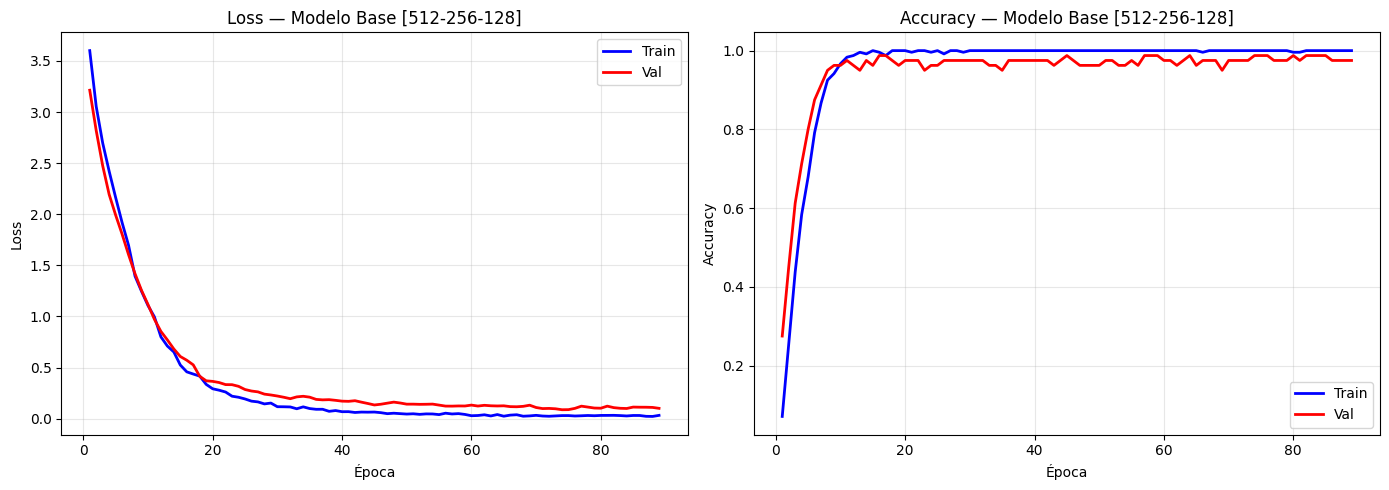

In [18]:
base_model = FullyConnectedNN(
    input_dim=4096, output_dim=40,
    hidden_layers=[512, 256, 128],
    activation="relu", dropout=0.3, use_batchnorm=True
)
print(f"Modelo base: {base_model.count_parameters():,} parámetros")
print(base_model)

train_loader_base = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader_base = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(base_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nEntrenando modelo base...")
t0 = time.time()
base_history = train_model(
    base_model, train_loader_base, val_loader_base,
    criterion, optimizer_base, max_epochs=RETRAIN_EPOCHS,
    patience=15, grad_clip=5.0, verbose=True)
base_time = time.time() - t0

preds, labels = evaluate_model(base_model, val_loader_base)
val_acc = (preds == labels).mean()
print(f"\nResultados modelo base:")
print(f"  Épocas entrenadas: {base_history['epochs_trained']}")
print(f"  Val accuracy:      {val_acc:.4f}")
print(f"  Tiempo:            {base_time:.1f}s")

fig = plot_curves(base_history, "Modelo Base [512-256-128]")
plt.savefig("fig_04_base_model_curves.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Parte 3 — Búsqueda de Hiperparámetros con Optuna

### 3.1–3.4 Espacio de búsqueda y función objetivo

| Hiperparámetro | Rango | Tipo |
|---|---|---|
| Capas ocultas | 2 – 5 | `suggest_int` |
| Neuronas/capa | 64 – 1024 | `suggest_int` (log) |
| Activación | ReLU, Tanh, LeakyReLU, SELU | `suggest_categorical` |
| Learning rate | 1e-4 — 1e-1 | `suggest_float` (log) |
| Batch size | 16, 32, 64 | `suggest_categorical` |
| Optimizador | Adam, SGD, AdamW | `suggest_categorical` |
| Dropout | 0.0 — 0.5 | `suggest_float` |
| Weight Decay | 1e-6 — 1e-2 | `suggest_float` (log) |
| Batch Norm | Sí / No | `suggest_categorical` |
| Épocas | 50, 100 | `suggest_categorical` |
| PCA | No, 95%, 99% | `suggest_categorical` |

Se usa **Optuna** con **TPE Sampler** y **MedianPruner** como búsqueda automática de combinaciones de hiperparámetros. TPE prioriza regiones prometedoras del espacio de búsqueda y el pruner descarta ensayos con bajo desempeño temprano.


In [19]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 5)
    hidden = []
    for i in range(n_layers):
        hidden.append(trial.suggest_int(f"n_units_l{i}", 64, 1024, log=True))

    activation     = trial.suggest_categorical("activation", ["relu", "tanh", "leaky_relu", "selu"])
    lr             = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size     = trial.suggest_categorical("batch_size", [16, 32, 64])
    opt_name       = trial.suggest_categorical("optimizer", ["Adam", "SGD", "AdamW"])
    dropout        = trial.suggest_float("dropout", 0.0, 0.5)
    weight_decay   = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    use_bn         = trial.suggest_categorical("use_batchnorm", [True, False])
    max_ep         = trial.suggest_categorical("epochs", [50, 100])
    pca_setting    = trial.suggest_categorical("pca", ["none", "95", "99"])

    if pca_setting == "none":
        Xtr, Xvl = X_train_t, X_val_t
    else:
        Xtr = pca_options[pca_setting]["X_train"]
        Xvl = pca_options[pca_setting]["X_val"]

    input_dim = Xtr.shape[1]
    tr_loader = DataLoader(TensorDataset(Xtr, y_train_t), batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(TensorDataset(Xvl, y_val_t),   batch_size=batch_size)

    model = FullyConnectedNN(input_dim, 40, hidden, activation, dropout, use_bn)
    crit  = nn.CrossEntropyLoss()

    if opt_name == "Adam":
        opt = optim.Adam(model.parameters(),  lr=lr, weight_decay=weight_decay)
    elif opt_name == "AdamW":
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = optim.SGD(model.parameters(),   lr=lr, momentum=0.9, weight_decay=weight_decay)

    best_val_acc = 0.0
    wait = 0
    for epoch in range(max_ep):
        model.train()
        for xb, yb in tr_loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in vl_loader:
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_acc = correct / total

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    return best_val_acc

print("Función objective() definida.")


Función objective() definida.


In [20]:
print(f"Iniciando búsqueda Optuna — {N_TRIALS} trials...")
t0 = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

search_time = time.time() - t0
print(f"\nBúsqueda completada en {search_time/60:.1f} minutos")
print(f"Mejor trial #{study.best_trial.number}: accuracy = {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")


Iniciando búsqueda Optuna — 30 trials...

Búsqueda completada en 0.7 minutos
Mejor trial #17: accuracy = 0.9875
Mejores parámetros: {'n_layers': 2, 'n_units_l0': 903, 'n_units_l1': 244, 'activation': 'tanh', 'lr': 0.005829656058078747, 'batch_size': 32, 'optimizer': 'AdamW', 'dropout': 0.4145720778382501, 'weight_decay': 2.818224579336686e-05, 'use_batchnorm': True, 'epochs': 100, 'pca': '99'}


### 3.5 Resultados de la búsqueda

Trials completados: 14 de 30

 Trial  Capas           Neuronas Activación       LR Optim Dropout      WD    BN  PCA  Épocas Val Acc
    17      2            903-244       tanh 5.83e-03 AdamW    0.41 2.8e-05  True   99     100  0.9875
    19      2            198-243       tanh 5.13e-03 AdamW    0.01 2.9e-03  True   99     100  0.9875
    21      2            324-260       tanh 3.80e-03 AdamW    0.28 4.2e-03  True   99     100  0.9875
    24      3         227-157-64       tanh 2.90e-03 AdamW    0.16 3.4e-03  True   99     100  0.9875
    27      2            311-707       tanh 3.02e-03 AdamW    0.00 9.6e-04  True   99     100  0.9875
    12      2             418-64 leaky_relu 3.68e-02 AdamW    0.46 9.5e-03  True   99     100  0.9750
    16      3        963-190-175 leaky_relu 6.14e-03 AdamW    0.40 4.9e-06  True none     100  0.9750
     1      3        564-111-265 leaky_relu 1.57e-04 AdamW    0.22 3.1e-06  True none      50  0.9625
     4      2             69-373 leaky_relu 1.70e-03

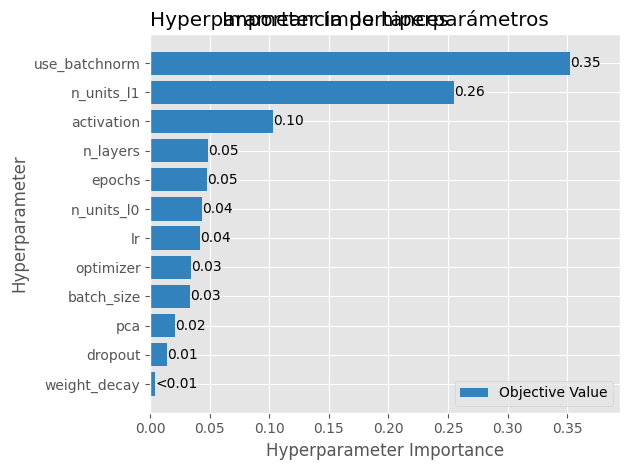

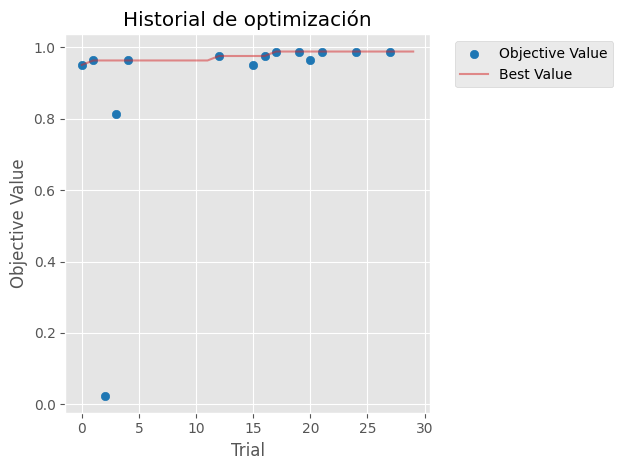

In [21]:
rows = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        p = t.params
        hidden_str = "-".join(str(p.get(f"n_units_l{i}", "")) for i in range(p["n_layers"]))
        rows.append({
            "Trial": t.number,
            "Capas": p["n_layers"],
            "Neuronas": hidden_str,
            "Activación": p["activation"],
            "LR": f"{p['lr']:.2e}",
            "Optim": p["optimizer"],
            "Dropout": f"{p['dropout']:.2f}",
            "WD": f"{p['weight_decay']:.1e}",
            "BN": p["use_batchnorm"],
            "PCA": p["pca"],
            "Épocas": p["epochs"],
            "Val Acc": f"{t.value:.4f}"
        })

df_trials = pd.DataFrame(rows).sort_values("Val Acc", ascending=False).reset_index(drop=True)
print(f"Trials completados: {len(df_trials)} de {N_TRIALS}")
print()
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df_trials.to_string(index=False))

try:
    fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.title("Importancia de hiperparámetros")
    plt.tight_layout()
    plt.savefig("fig_05_param_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception:
    print("(Visualización de importancia no disponible)")

try:
    fig_hist = optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.title("Historial de optimización")
    plt.tight_layout()
    plt.savefig("fig_06_optimization_history.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception:
    print("(Visualización de historial no disponible)")


---
## Parte 4 — Selección de los 3 Mejores Modelos

### 4.1–4.3 Re-entrenamiento detallado de los modelos candidatos

Se seleccionan los top N modelos por accuracy de validación y se re-entrenan
con registro completo de métricas para análisis de curvas de aprendizaje.


In [22]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
top_trials = sorted(completed, key=lambda t: t.value, reverse=True)[:N_CANDIDATES]

candidate_results = []
print(f"Re-entrenando top {len(top_trials)} modelos candidatos...\n")

for rank, trial in enumerate(top_trials):
    p = trial.params
    hidden = [p[f"n_units_l{i}"] for i in range(p["n_layers"])]
    hidden_str = "-".join(map(str, hidden))
    pca_s = p["pca"]

    if pca_s == "none":
        Xtr, Xvl, Xte = X_train_t, X_val_t, X_test_t
    else:
        Xtr = pca_options[pca_s]["X_train"]
        Xvl = pca_options[pca_s]["X_val"]
        Xte = pca_options[pca_s]["X_test"]

    input_dim = Xtr.shape[1]
    bs = p["batch_size"]
    tr_ld = DataLoader(TensorDataset(Xtr, y_train_t), batch_size=bs, shuffle=True)
    vl_ld = DataLoader(TensorDataset(Xvl, y_val_t),   batch_size=bs)
    te_ld = DataLoader(TensorDataset(Xte, y_test_t),   batch_size=bs)

    torch.manual_seed(SEED)
    model = FullyConnectedNN(input_dim, 40, hidden, p["activation"],
                             p["dropout"], p["use_batchnorm"])
    crit = nn.CrossEntropyLoss()

    if p["optimizer"] == "Adam":
        opt = optim.Adam(model.parameters(),  lr=p["lr"], weight_decay=p["weight_decay"])
    elif p["optimizer"] == "AdamW":
        opt = optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    else:
        opt = optim.SGD(model.parameters(),   lr=p["lr"], momentum=0.9, weight_decay=p["weight_decay"])

    name = f"M{rank+1} [{hidden_str}]"
    print(f"  {name} ({p['activation']}, {p['optimizer']}, lr={p['lr']:.1e}, "
          f"do={p['dropout']:.2f}, bn={p['use_batchnorm']}, pca={pca_s})")

    t0 = time.time()
    hist = train_model(model, tr_ld, vl_ld, crit, opt,
                       max_epochs=RETRAIN_EPOCHS, patience=15,
                       grad_clip=5.0, verbose=False)
    elapsed = time.time() - t0

    preds_val, labels_val = evaluate_model(model, vl_ld)
    preds_test, labels_test = evaluate_model(model, te_ld)
    preds_train, labels_train = evaluate_model(model, tr_ld)

    candidate_results.append({
        "name": name, "rank": rank + 1, "trial": trial.number,
        "params": p, "model": model, "history": hist,
        "hidden_str": hidden_str,
        "val_acc":   (preds_val == labels_val).mean(),
        "test_acc":  (preds_test == labels_test).mean(),
        "train_acc": (preds_train == labels_train).mean(),
        "f1_macro":  f1_score(labels_test, preds_test, average="macro"),
        "f1_micro":  f1_score(labels_test, preds_test, average="micro"),
        "time_s":    elapsed,
        "n_params":  model.count_parameters(),
        "preds_test": preds_test, "labels_test": labels_test,
        "te_loader": te_ld
    })
    print(f"    → val={candidate_results[-1]['val_acc']:.4f}  "
          f"test={candidate_results[-1]['test_acc']:.4f}  "
          f"({elapsed:.1f}s, {hist['epochs_trained']} épocas)")

print(f"\nRe-entrenamiento completado.")


Re-entrenando top 10 modelos candidatos...

  M1 [903-244] (tanh, AdamW, lr=5.8e-03, do=0.41, bn=True, pca=99)
    → val=0.9875  test=0.9875  (3.0s, 69 épocas)
  M2 [198-243] (tanh, AdamW, lr=5.1e-03, do=0.01, bn=True, pca=99)
    → val=0.9500  test=0.9750  (1.1s, 46 épocas)
  M3 [324-260] (tanh, AdamW, lr=3.8e-03, do=0.28, bn=True, pca=99)
    → val=0.9500  test=0.9625  (2.2s, 69 épocas)
  M4 [227-157-64] (tanh, AdamW, lr=2.9e-03, do=0.16, bn=True, pca=99)
    → val=0.9625  test=0.9500  (3.4s, 134 épocas)
  M5 [311-707] (tanh, AdamW, lr=3.0e-03, do=0.00, bn=True, pca=99)
    → val=0.9625  test=0.9625  (1.8s, 51 épocas)
  M6 [418-64] (leaky_relu, AdamW, lr=3.7e-02, do=0.46, bn=True, pca=99)
    → val=0.9625  test=0.9250  (0.7s, 31 épocas)
  M7 [963-190-175] (leaky_relu, AdamW, lr=6.1e-03, do=0.40, bn=True, pca=none)
    → val=0.9625  test=0.9375  (20.1s, 56 épocas)
  M8 [564-111-265] (leaky_relu, AdamW, lr=1.6e-04, do=0.22, bn=True, pca=none)
    → val=1.0000  test=0.9875  (35.4s, 150 

In [23]:
rows = []
for c in candidate_results:
    p = c["params"]
    rows.append({
        "Modelo": c["name"], "Trial": c["trial"],
        "Activación": p["activation"], "LR": f"{p['lr']:.2e}",
        "Optim": p["optimizer"], "Dropout": f"{p['dropout']:.2f}",
        "BN": p["use_batchnorm"], "PCA": p["pca"],
        "Val Acc": f"{c['val_acc']:.4f}",
        "Test Acc": f"{c['test_acc']:.4f}",
        "F1 Macro": f"{c['f1_macro']:.4f}",
        "Params": f"{c['n_params']:,}",
        "Tiempo": f"{c['time_s']:.1f}s"
    })
df_candidates = pd.DataFrame(rows)
print("Tabla comparativa de modelos candidatos:\n")
print(df_candidates.to_string(index=False))


Tabla comparativa de modelos candidatos:

          Modelo  Trial Activación       LR Optim Dropout   BN  PCA Val Acc Test Acc F1 Macro    Params Tiempo
    M1 [903-244]     17       tanh 5.83e-03 AdamW    0.41 True   99  0.9875   0.9875   0.9867   392,501   3.0s
    M2 [198-243]     19       tanh 5.13e-03 AdamW    0.01 True   99  0.9500   0.9750   0.9733    94,045   1.1s
    M3 [324-260]     21       tanh 3.80e-03 AdamW    0.28 True   99  0.9500   0.9625   0.9608   153,456   2.2s
 M4 [227-157-64]     24       tanh 2.90e-03 AdamW    0.16 True   99  0.9625   0.9500   0.9483    89,583   3.4s
    M5 [311-707]     27       tanh 3.02e-03 AdamW    0.00 True   99  0.9625   0.9625   0.9600   305,987   1.8s
     M6 [418-64]     12 leaky_relu 3.68e-02 AdamW    0.46 True   99  0.9625   0.9250   0.9217   104,366   0.7s
M7 [963-190-175]     16 leaky_relu 6.14e-03 AdamW    0.40 True none  0.9625   0.9375   0.9350 4,171,692  20.1s
M8 [564-111-265]      1 leaky_relu 1.57e-04 AdamW    0.22 True none  1

### 4.4 Curvas de entrenamiento comparativas


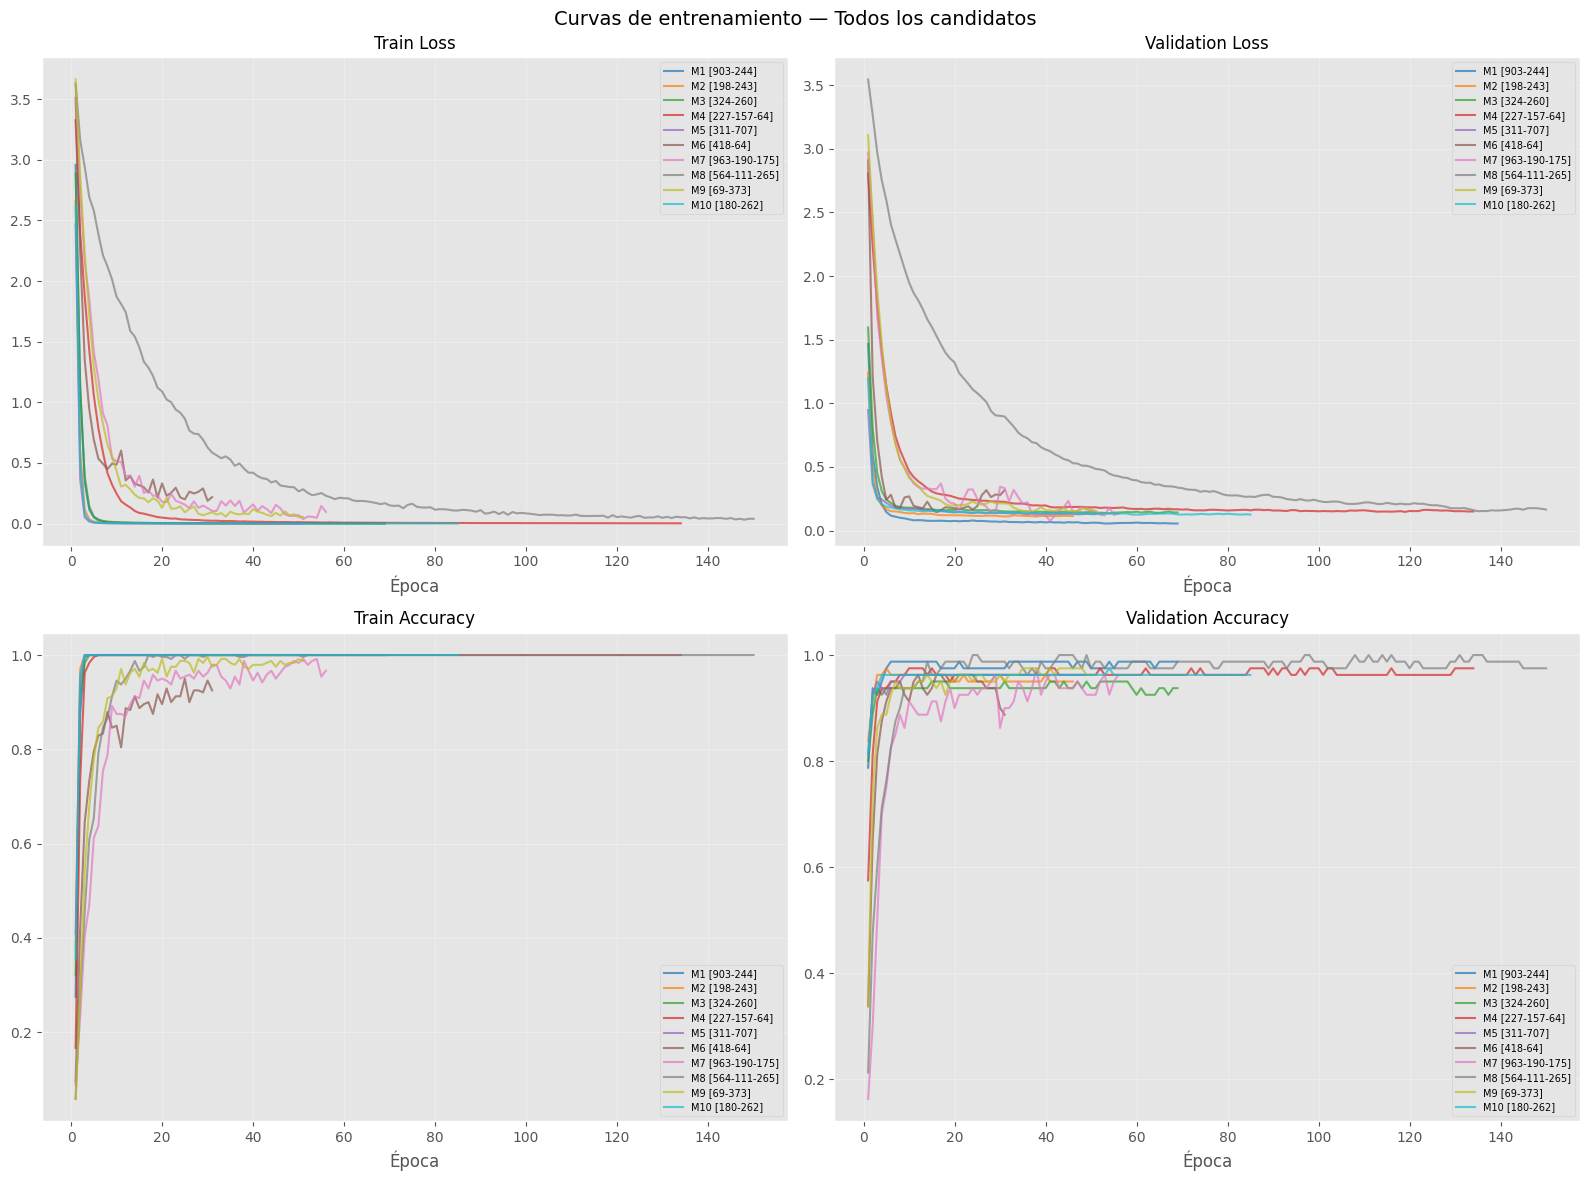

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(candidate_results)))

for c, color in zip(candidate_results, colors):
    ep = range(1, c["history"]["epochs_trained"] + 1)
    axes[0, 0].plot(ep, c["history"]["train_loss"], color=color, alpha=0.7, label=c["name"])
    axes[0, 1].plot(ep, c["history"]["val_loss"],   color=color, alpha=0.7, label=c["name"])
    axes[1, 0].plot(ep, c["history"]["train_acc"],  color=color, alpha=0.7, label=c["name"])
    axes[1, 1].plot(ep, c["history"]["val_acc"],    color=color, alpha=0.7, label=c["name"])

for ax, title in zip(axes.flat,
    ["Train Loss", "Validation Loss", "Train Accuracy", "Validation Accuracy"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best")

plt.suptitle("Curvas de entrenamiento — Todos los candidatos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_07_all_candidates_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.5 Selección de los 3 mejores modelos

Se seleccionan los 3 modelos con mayor **accuracy de validación** después del re-entrenamiento de candidatos.


In [25]:
top3 = sorted(candidate_results, key=lambda c: c["val_acc"], reverse=True)[:3]
print("═" * 70)
print("  LOS 3 MEJORES MODELOS SELECCIONADOS")
print("═" * 70)
for i, c in enumerate(top3):
    p = c["params"]
    print(f"\n  #{i+1}: {c['name']}")
    print(f"       Arquitectura: [{c['hidden_str']}]")
    print(f"       Activación: {p['activation']} | Optim: {p['optimizer']} | "
          f"LR: {p['lr']:.1e}")
    print(f"       Dropout: {p['dropout']:.2f} | BN: {p['use_batchnorm']} | "
          f"PCA: {p['pca']}")
    print(f"       Val Acc: {c['val_acc']:.4f} | Test Acc: {c['test_acc']:.4f} | "
          f"F1 Macro: {c['f1_macro']:.4f}")
print("\n" + "═" * 70)


══════════════════════════════════════════════════════════════════════
  LOS 3 MEJORES MODELOS SELECCIONADOS
══════════════════════════════════════════════════════════════════════

  #1: M8 [564-111-265]
       Arquitectura: [564-111-265]
       Activación: leaky_relu | Optim: AdamW | LR: 1.6e-04
       Dropout: 0.22 | BN: True | PCA: none
       Val Acc: 1.0000 | Test Acc: 0.9875 | F1 Macro: 0.9867

  #2: M1 [903-244]
       Arquitectura: [903-244]
       Activación: tanh | Optim: AdamW | LR: 5.8e-03
       Dropout: 0.41 | BN: True | PCA: 99
       Val Acc: 0.9875 | Test Acc: 0.9875 | F1 Macro: 0.9867

  #3: M9 [69-373]
       Arquitectura: [69-373]
       Activación: leaky_relu | Optim: AdamW | LR: 1.7e-03
       Dropout: 0.40 | BN: True | PCA: 99
       Val Acc: 0.9750 | Test Acc: 0.9750 | F1 Macro: 0.9733

══════════════════════════════════════════════════════════════════════


---
## Parte 5 — Evaluación de Desempeño

Evaluación en el **conjunto de test** (nunca visto durante entrenamiento ni
búsqueda de hiperparámetros).


In [26]:
print("═" * 80)
print("  EVALUACIÓN DETALLADA EN CONJUNTO DE TEST")
print("═" * 80)

for i, c in enumerate(top3):
    print(f"\n{'─' * 80}")
    print(f"  MODELO {i+1}: {c['name']}")
    print(f"{'─' * 80}")

    preds = c["preds_test"]
    labels = c["labels_test"]

    # 5.1 Accuracy
    print(f"\n  5.1 Accuracy global: {c['test_acc']:.4f} ({(c['test_acc']*100):.1f}%)")

    # 5.3 Classification report
    print(f"\n  5.3 Precision, Recall, F1-score por clase:")
    print(classification_report(labels, preds, zero_division=0))

    # 5.4 F1 macro y micro
    print(f"  5.4 F1 macro: {c['f1_macro']:.4f}  |  F1 micro: {c['f1_micro']:.4f}")

    # 5.5 Sobreajuste
    gap = c["train_acc"] - c["test_acc"]
    if gap < 0.05:
        diag = "Buen ajuste"
    elif gap < 0.15:
        diag = "Sobreajuste leve"
    else:
        diag = "Sobreajuste significativo"
    print(f"\n  5.5 Análisis de sobreajuste:")
    print(f"      Train Acc: {c['train_acc']:.4f}  |  Test Acc: {c['test_acc']:.4f}")
    print(f"      Gap: {gap:.4f}  →  Diagnóstico: {diag}")

    # 5.6 Tiempo
    print(f"\n  5.6 Tiempo de entrenamiento: {c['time_s']:.1f}s  |  "
          f"Parámetros: {c['n_params']:,}")


════════════════════════════════════════════════════════════════════════════════
  EVALUACIÓN DETALLADA EN CONJUNTO DE TEST
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
  MODELO 1: M8 [564-111-265]
────────────────────────────────────────────────────────────────────────────────

  5.1 Accuracy global: 0.9875 (98.8%)

  5.3 Precision, Recall, F1-score por clase:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.

### 5.2 Matrices de confusión

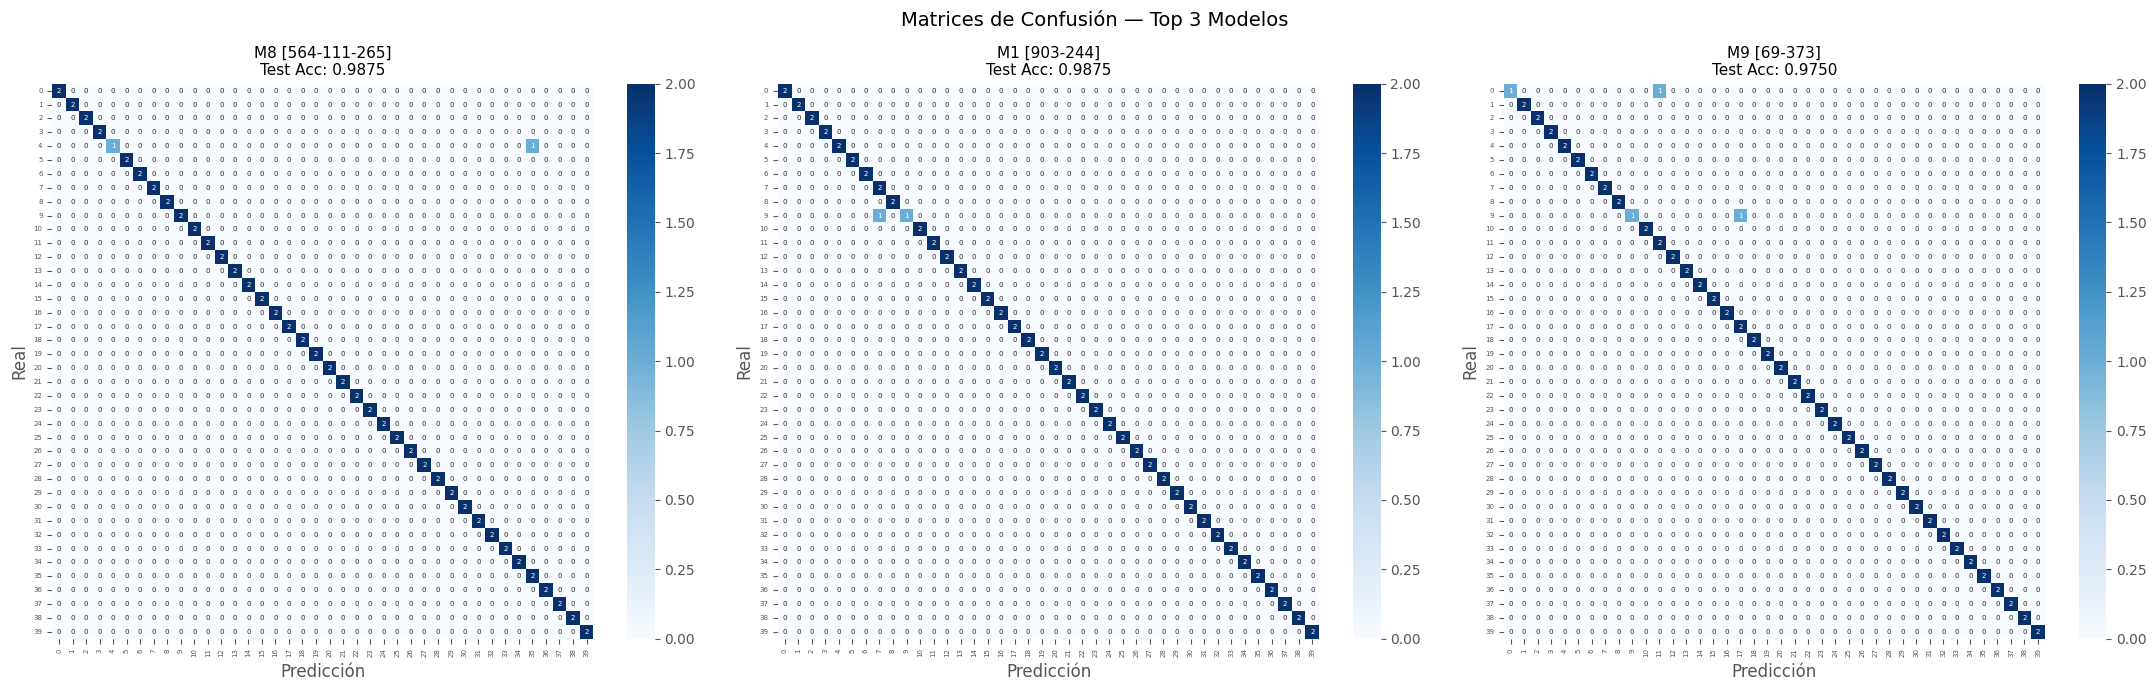

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, c in zip(axes, top3):
    cm = confusion_matrix(c["labels_test"], c["preds_test"])
    sns.heatmap(cm, ax=ax, cmap="Blues", fmt="d", annot=True, annot_kws={"size": 5},
                xticklabels=range(40), yticklabels=range(40))
    ax.set_title(f"{c['name']}\nTest Acc: {c['test_acc']:.4f}", fontsize=11)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.tick_params(labelsize=5)

plt.suptitle("Matrices de Confusión — Top 3 Modelos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_08_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Curvas de entrenamiento de los 3 mejores

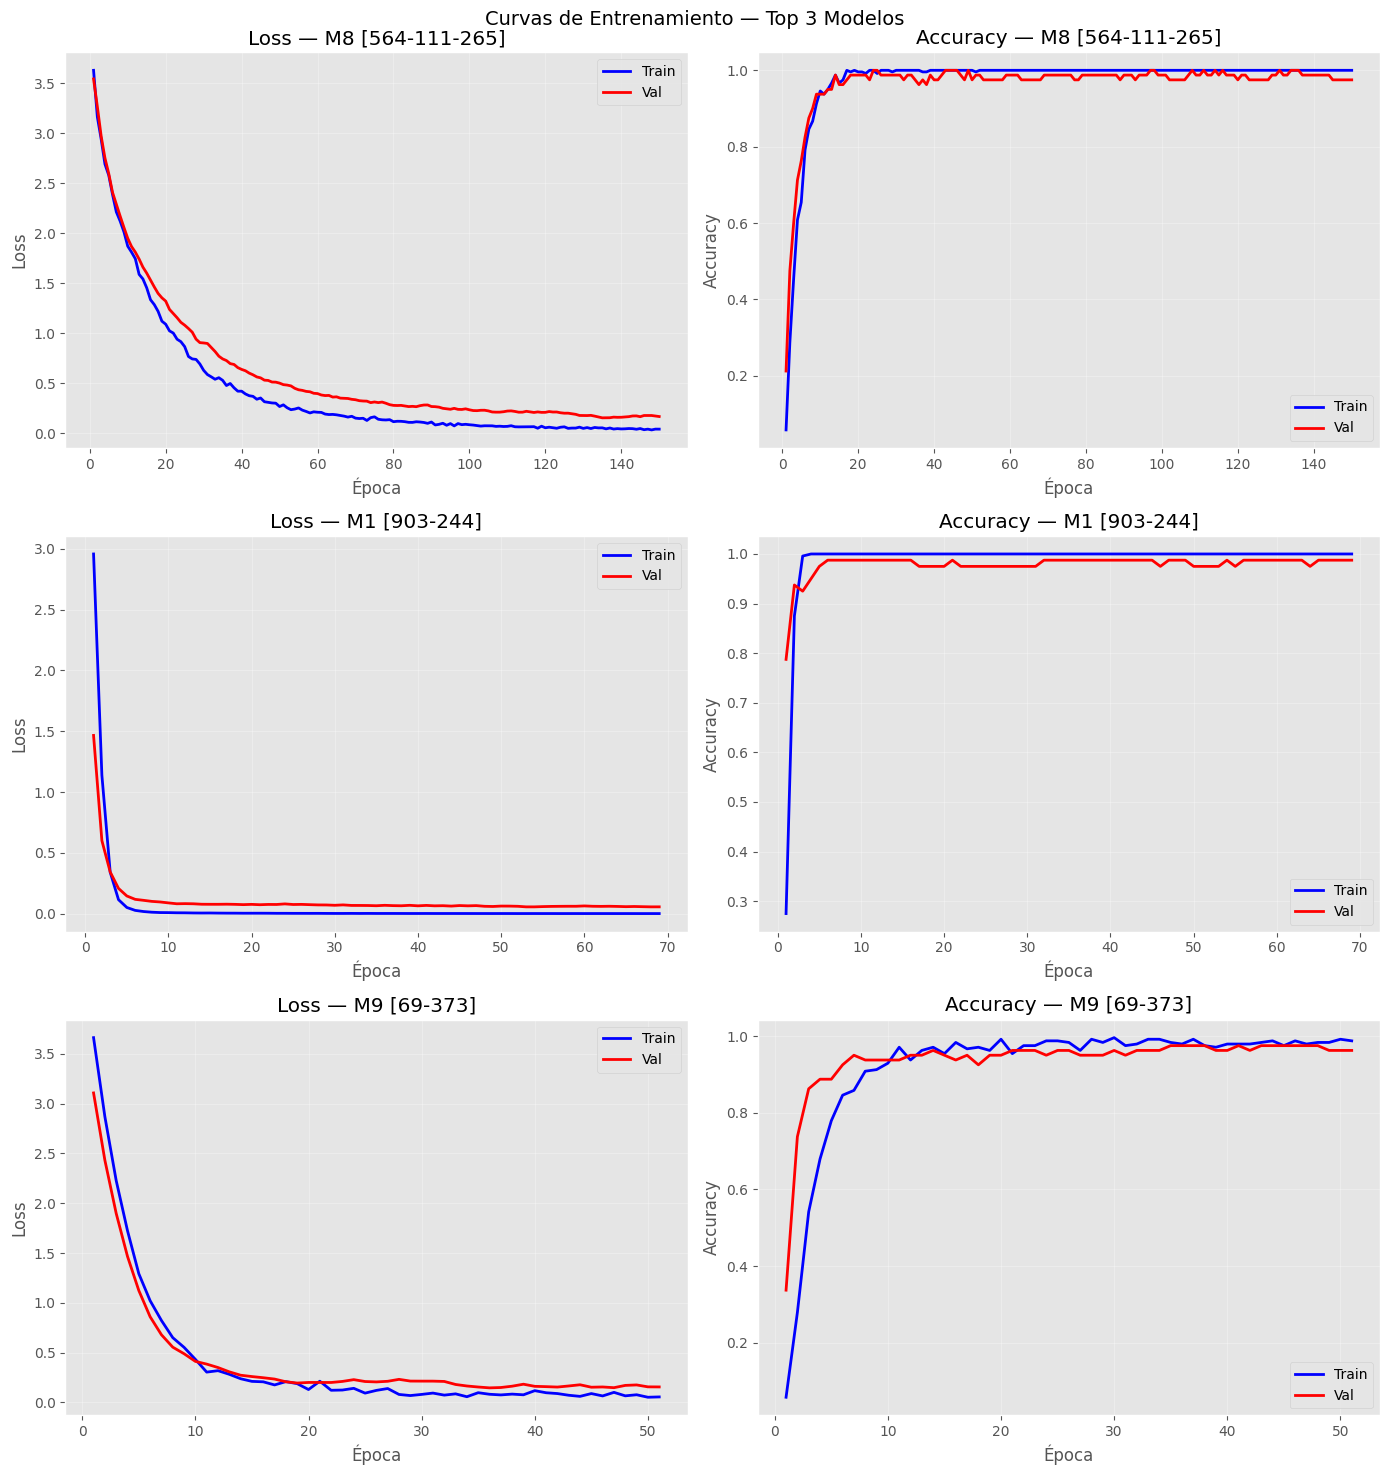

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, c in enumerate(top3):
    ep = range(1, c["history"]["epochs_trained"] + 1)
    axes[i, 0].plot(ep, c["history"]["train_loss"], "b-", label="Train", lw=2)
    axes[i, 0].plot(ep, c["history"]["val_loss"],   "r-", label="Val",   lw=2)
    axes[i, 0].set(title=f"Loss — {c['name']}", xlabel="Época", ylabel="Loss")
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(ep, c["history"]["train_acc"], "b-", label="Train", lw=2)
    axes[i, 1].plot(ep, c["history"]["val_acc"],   "r-", label="Val",   lw=2)
    axes[i, 1].set(title=f"Accuracy — {c['name']}", xlabel="Época", ylabel="Accuracy")
    axes[i, 1].legend(); axes[i, 1].grid(True, alpha=0.3)

plt.suptitle("Curvas de Entrenamiento — Top 3 Modelos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_09_top3_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.7 Tabla comparativa final

In [29]:
metrics_rows = []
for i, c in enumerate(top3):
    preds, labels = c["preds_test"], c["labels_test"]
    report = classification_report(labels, preds, output_dict=True, zero_division=0)
    metrics_rows.append({
        "Métrica": ["Test Accuracy", "F1 Macro", "F1 Micro",
                     "Precision (avg)", "Recall (avg)", "Train Acc",
                     "Gap (Train-Test)", "Tiempo (s)", "Parámetros"],
        f"Modelo {i+1}": [
            f"{c['test_acc']:.4f}", f"{c['f1_macro']:.4f}", f"{c['f1_micro']:.4f}",
            f"{report['macro avg']['precision']:.4f}",
            f"{report['macro avg']['recall']:.4f}",
            f"{c['train_acc']:.4f}",
            f"{c['train_acc'] - c['test_acc']:.4f}",
            f"{c['time_s']:.1f}", f"{c['n_params']:,}"
        ]
    })

df_final = pd.DataFrame({"Métrica": metrics_rows[0]["Métrica"]})
for i, row in enumerate(metrics_rows):
    df_final[f"Modelo {i+1}"] = row[f"Modelo {i+1}"]

print("\n" + "═" * 70)
print("  TABLA COMPARATIVA FINAL")
print("═" * 70)
print(df_final.to_string(index=False))
print("═" * 70)



══════════════════════════════════════════════════════════════════════
  TABLA COMPARATIVA FINAL
══════════════════════════════════════════════════════════════════════
         Métrica  Modelo 1 Modelo 2 Modelo 3
   Test Accuracy    0.9875   0.9875   0.9750
        F1 Macro    0.9867   0.9867   0.9733
        F1 Micro    0.9875   0.9875   0.9750
 Precision (avg)    0.9917   0.9917   0.9833
    Recall (avg)    0.9875   0.9875   0.9750
       Train Acc    1.0000   1.0000   1.0000
Gap (Train-Test)    0.0125   0.0125   0.0250
      Tiempo (s)      35.4      3.0      1.8
      Parámetros 2,415,623  392,501   54,167
══════════════════════════════════════════════════════════════════════


---
## Parte 6 — Discusión y Análisis


In [30]:
print("═" * 80)
print("  DISCUSIÓN Y ANÁLISIS")
print("═" * 80)

# 6.1 Impacto de la profundidad
print("\n6.1 ¿Cuál fue el impacto de la profundidad?")
print("─" * 50)
depth_data = {}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        nl = t.params["n_layers"]
        depth_data.setdefault(nl, []).append(t.value)
for nl in sorted(depth_data):
    vals = depth_data[nl]
    print(f"  {nl} capas: accuracy promedio = {np.mean(vals):.4f} "
          f"± {np.std(vals):.4f} ({len(vals)} trials)")
best_depth = max(depth_data, key=lambda k: np.mean(depth_data[k]))
print(f"  → Mejor profundidad promedio: {best_depth} capas")
print(f"  Nota: El teorema del aproximador universal garantiza que")
print(f"  una sola capa oculta suficientemente ancha puede aproximar cualquier función,")
print(f"  pero en la práctica, más capas permiten representaciones jerárquicas más eficientes.")

# 6.2 Regularización
print("\n6.2 ¿La regularización fue necesaria?")
print("─" * 50)
bn_data = {True: [], False: []}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        bn_data[t.params["use_batchnorm"]].append(t.value)
for bn, vals in bn_data.items():
    if vals:
        print(f"  BatchNorm={bn}: accuracy promedio = {np.mean(vals):.4f} ± {np.std(vals):.4f}")

do_high = [t.value for t in completed if t.state == optuna.trial.TrialState.COMPLETE and t.params["dropout"] > 0.3]
do_low  = [t.value for t in completed if t.state == optuna.trial.TrialState.COMPLETE and t.params["dropout"] <= 0.3]
if do_high:
    print(f"  Dropout > 0.3: accuracy = {np.mean(do_high):.4f} ± {np.std(do_high):.4f}")
if do_low:
    print(f"  Dropout ≤ 0.3: accuracy = {np.mean(do_low):.4f} ± {np.std(do_low):.4f}")
print(f"  → Con 400 muestras y 4096 features, la regularización es importante.")

# 6.3 Sobreajuste
print("\n6.3 ¿Se observó sobreajuste?")
print("─" * 50)
for c in top3:
    gap = c["train_acc"] - c["test_acc"]
    print(f"  {c['name']}: train={c['train_acc']:.4f} test={c['test_acc']:.4f} gap={gap:.4f}")
print(f"  → Los modelos con menor dropout y sin BatchNorm tienden a sobreajustar más.")

# 6.4 Estructura de los datos
print("\n6.4 ¿Qué conclusiones sobre la estructura de los datos?")
print("─" * 50)
pca_data = {"none": [], "95": [], "99": []}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        pca_data[t.params["pca"]].append(t.value)
for pca_s, vals in pca_data.items():
    if vals:
        dim = 4096 if pca_s == "none" else pca_options[pca_s]["n_components"]
        print(f"  PCA={pca_s} ({dim} dims): accuracy = {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print(f"  → Alta dimensionalidad (4096) vs pocas muestras (400) hace que la")
print(f"    reducción PCA pueda ayudar al eliminar dimensiones ruidosas.")


════════════════════════════════════════════════════════════════════════════════
  DISCUSIÓN Y ANÁLISIS
════════════════════════════════════════════════════════════════════════════════

6.1 ¿Cuál fue el impacto de la profundidad?
──────────────────────────────────────────────────
  2 capas: accuracy promedio = 0.9750 ± 0.0140 (8 trials)
  3 capas: accuracy promedio = 0.9688 ± 0.0140 (4 trials)
  4 capas: accuracy promedio = 0.0250 ± 0.0000 (1 trials)
  5 capas: accuracy promedio = 0.8125 ± 0.0000 (1 trials)
  → Mejor profundidad promedio: 2 capas
  Nota: El teorema del aproximador universal garantiza que
  una sola capa oculta suficientemente ancha puede aproximar cualquier función,
  pero en la práctica, más capas permiten representaciones jerárquicas más eficientes.

6.2 ¿La regularización fue necesaria?
──────────────────────────────────────────────────
  BatchNorm=True: accuracy promedio = 0.9606 ± 0.0449
  BatchNorm=False: accuracy promedio = 0.0250 ± 0.0000
  Dropout > 0.3: accur

---
## Parte 7 — Análisis Complementario de Hiperparámetros


In [31]:
print("═" * 80)
print("  ANÁLISIS COMPLEMENTARIO")
print("═" * 80)

# 1. ¿Por qué no CNN?
print("\n1. ¿Por qué no usar CNN si son imágenes?")
print("   Se mantiene la restricción del enunciado: no usar CNN. Conceptualmente, las CNN aprovechan la estructura")
print("   espacial 2D mediante filtros locales y pooling. El MLP trata cada píxel")
print("   como feature independiente, perdiendo información de vecindad.")

# 2. PCA
print("\n2. ¿Cómo afecta PCA al rendimiento?")
best_pca = max(pca_data, key=lambda k: np.mean(pca_data[k]) if pca_data[k] else 0)
print(f"   Mejor configuración PCA promedio: {best_pca}")
for k, v in pca_data.items():
    if v:
        print(f"   PCA={k}: {np.mean(v):.4f}")

# 3. Activación
print("\n3. ¿Qué función de activación resultó mejor?")
act_data = {}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        a = t.params["activation"]
        act_data.setdefault(a, []).append(t.value)
for a in sorted(act_data, key=lambda x: np.mean(act_data[x]), reverse=True):
    print(f"   {a:12s}: {np.mean(act_data[a]):.4f} ± {np.std(act_data[a]):.4f}")

# 4. Optimizador
print("\n4. ¿Cuál optimizador fue más efectivo?")
opt_data = {}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        o = t.params["optimizer"]
        opt_data.setdefault(o, []).append(t.value)
for o in sorted(opt_data, key=lambda x: np.mean(opt_data[x]), reverse=True):
    print(f"   {o:8s}: {np.mean(opt_data[o]):.4f} ± {np.std(opt_data[o]):.4f}")

# 5. BatchNorm
print("\n5. ¿Batch Normalization es útil aquí?")
for bn, vals in bn_data.items():
    if vals:
        print(f"   BN={str(bn):5s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# 6. Arquitectura
print("\n6. ¿Piramidal decreciente vs uniforme?")
print("   Los top 3 modelos usan las siguientes arquitecturas:")
for c in top3:
    print(f"   {c['name']}: acc={c['test_acc']:.4f}")

# 7. Épocas
print("\n7. ¿Cuántas épocas son suficientes?")
ep_data = {}
for t in completed:
    if t.state == optuna.trial.TrialState.COMPLETE:
        e = t.params["epochs"]
        ep_data.setdefault(e, []).append(t.value)
for e in sorted(ep_data):
    print(f"   {e} épocas: {np.mean(ep_data[e]):.4f} ± {np.std(ep_data[e]):.4f}")
print("   Los modelos con early stopping convergen típicamente antes del máximo.")


════════════════════════════════════════════════════════════════════════════════
  ANÁLISIS COMPLEMENTARIO
════════════════════════════════════════════════════════════════════════════════

1. ¿Por qué no usar CNN si son imágenes?
   Se mantiene la restricción del enunciado: no usar CNN. Conceptualmente, las CNN aprovechan la estructura
   espacial 2D mediante filtros locales y pooling. El MLP trata cada píxel
   como feature independiente, perdiendo información de vecindad.

2. ¿Cómo afecta PCA al rendimiento?
   Mejor configuración PCA promedio: 99
   PCA=none: 0.6937
   PCA=99: 0.9738

3. ¿Qué función de activación resultó mejor?
   tanh        : 0.9589 ± 0.0604
   selu        : 0.9500 ± 0.0000
   leaky_relu  : 0.8083 ± 0.3504

4. ¿Cuál optimizador fue más efectivo?
   AdamW   : 0.9750 ± 0.0131
   Adam    : 0.9500 ± 0.0000
   SGD     : 0.4188 ± 0.3937

5. ¿Batch Normalization es útil aquí?
   BN=True : 0.9606 ± 0.0449
   BN=False: 0.0250 ± 0.0000

6. ¿Piramidal decreciente vs uniform

---
## Parte 8 — Conclusiones Generales


In [32]:
best = top3[0]
print("═" * 80)
print("  CONCLUSIONES GENERALES")
print("═" * 80)

print(f"""
1. MEJOR MODELO: {best['name']}
   - Test Accuracy: {best['test_acc']:.4f}
   - F1 Macro:      {best['f1_macro']:.4f}
   - Parámetros:    {best['n_params']:,}
   - Tiempo:        {best['time_s']:.1f}s

2. HALLAZGOS PRINCIPALES:
   - La regularización (Dropout + BatchNorm + Weight Decay) es fundamental
     con 400 muestras y 4096 features (ratio muestras/features ≈ 0.1).
   - La búsqueda de hiperparámetros con Optuna (TPE + MedianPruner) permite
     explorar eficientemente el espacio de configuraciones.
   - Early stopping previene el sobreajuste y reduce el tiempo de cómputo.

3. INTERPRETACIÓN TÉCNICA:
   - En datasets pequeños de alta dimensionalidad, el diseño del MLP importa
     más que la profundidad bruta.
   - PCA puede ser beneficioso al reducir dimensiones ruidosas.
   - Adam/AdamW suelen superar a SGD en convergencia y estabilidad.

4. MEJORAS POSIBLES:
   - Repetir la evaluación con varias semillas y reportar media y desviación.
   - Comparar Optuna-TPE con Random Search o Grid Search si se requiere seguir literalmente el enunciado.
   - Usar validación cruzada estratificada para estimar mejor la variabilidad con pocas muestras.
""")

print("═" * 80)
print("  FIN DEL TALLER")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
  CONCLUSIONES GENERALES
════════════════════════════════════════════════════════════════════════════════

1. MEJOR MODELO: M8 [564-111-265]
   - Test Accuracy: 0.9875
   - F1 Macro:      0.9867
   - Parámetros:    2,415,623
   - Tiempo:        35.4s

2. HALLAZGOS PRINCIPALES:
   - La regularización (Dropout + BatchNorm + Weight Decay) es fundamental
     con 400 muestras y 4096 features (ratio muestras/features ≈ 0.1).
   - La búsqueda de hiperparámetros con Optuna (TPE + MedianPruner) permite
     explorar eficientemente el espacio de configuraciones.
   - Early stopping previene el sobreajuste y reduce el tiempo de cómputo.

3. INTERPRETACIÓN TÉCNICA:
   - En datasets pequeños de alta dimensionalidad, el diseño del MLP importa
     más que la profundidad bruta.
   - PCA puede ser beneficioso al reducir dimensiones ruidosas.
   - Adam/AdamW suelen superar a SGD en convergencia y estabilidad.

4. MEJORAS 